# EfficientNet gender with training on age

In [1]:
import pandas as pd
import torch

In [2]:
# Load the data
df = pd.read_csv('./faces/fold_0_data.txt', sep="\t")

In [3]:
print(df.shape)
print(df.columns)
df.head()

(4484, 12)
Index(['user_id', 'original_image', 'face_id', 'age', 'gender', 'x', 'y', 'dx',
       'dy', 'tilt_ang', 'fiducial_yaw_angle', 'fiducial_score'],
      dtype='object')


,user_id,original_image,face_id,age,gender,x,y,dx,dy,tilt_ang,fiducial_yaw_angle,fiducial_score
0,30601258@N03,10399646885_67c7d20df9_o.jpg,1,"(25, 32)",f,0,414,1086,1383,-115,30,17
1,30601258@N03,10424815813_e94629b1ec_o.jpg,2,"(25, 32)",m,301,105,640,641,0,0,94
2,30601258@N03,10437979845_5985be4b26_o.jpg,1,"(25, 32)",f,2395,876,771,771,175,-30,74
3,30601258@N03,10437979845_5985be4b26_o.jpg,3,"(25, 32)",m,752,1255,484,485,180,0,47
4,30601258@N03,11816644924_075c3d8d59_o.jpg,2,"(25, 32)",m,175,80,769,768,-75,0,34


In [4]:
# Load the other dataframes
df1 = pd.read_csv('./faces/fold_1_data.txt', sep="\t")
df2 = pd.read_csv('./faces/fold_2_data.txt', sep="\t")
df3 = pd.read_csv('./faces/fold_3_data.txt', sep="\t")
df4 = pd.read_csv('./faces/fold_4_data.txt', sep="\t")

# Concatenate all the dataframes
df = pd.concat([df, df1, df2, df3, df4]).reset_index(drop=True)

In [5]:
print(df.shape)
print(df.columns)
df.head()

(19370, 12)
Index(['user_id', 'original_image', 'face_id', 'age', 'gender', 'x', 'y', 'dx',
       'dy', 'tilt_ang', 'fiducial_yaw_angle', 'fiducial_score'],
      dtype='object')


,user_id,original_image,face_id,age,gender,x,y,dx,dy,tilt_ang,fiducial_yaw_angle,fiducial_score
0,30601258@N03,10399646885_67c7d20df9_o.jpg,1,"(25, 32)",f,0,414,1086,1383,-115,30,17
1,30601258@N03,10424815813_e94629b1ec_o.jpg,2,"(25, 32)",m,301,105,640,641,0,0,94
2,30601258@N03,10437979845_5985be4b26_o.jpg,1,"(25, 32)",f,2395,876,771,771,175,-30,74
3,30601258@N03,10437979845_5985be4b26_o.jpg,3,"(25, 32)",m,752,1255,484,485,180,0,47
4,30601258@N03,11816644924_075c3d8d59_o.jpg,2,"(25, 32)",m,175,80,769,768,-75,0,34


In [6]:
# Create a new column with the path to the images
df['path'] = df['user_id'] + '/' + "coarse_tilt_aligned_face." + df['face_id'].astype(str) + "." + df['original_image']
df['path'].head()

0    30601258@N03/coarse_tilt_aligned_face.1.103996...
1    30601258@N03/coarse_tilt_aligned_face.2.104248...
2    30601258@N03/coarse_tilt_aligned_face.1.104379...
3    30601258@N03/coarse_tilt_aligned_face.3.104379...
4    30601258@N03/coarse_tilt_aligned_face.2.118166...
Name: path, dtype: object

In [7]:
# drop duplicate images
df = df.drop_duplicates(subset=['path'], keep='first').reset_index(drop=True)

In [8]:
df.shape

(19370, 13)

In [9]:
# Map the age values to the specified ranges 
# There are 8 unique values in the age column: 0-2, 4-6, 8-13, 15-20, 25-32, 38-43, 48-53, 60+
age_mapping = [('(0, 2)', '0-2'), ('2', '0-2'), ('3', '0-2'), ('(4, 6)', '4-6'), ('(8, 12)', '8-13'), ('13', '8-13'), ('22', '15-20'), ('(8, 23)','15-20'), ('23', '25-32'), ('(15, 20)', '15-20'), ('(25, 32)', '25-32'), ('(27, 32)', '25-32'), ('32', '25-32'), ('34', '25-32'), ('29', '25-32'), ('(38, 42)', '38-43'), ('35', '38-43'), ('36', '38-43'), ('42', '48-53'), ('45', '38-43'), ('(38, 43)', '38-43'), ('(38, 42)', '38-43'), ('(38, 48)', '48-53'), ('46', '48-53'), ('(48, 53)', '48-53'), ('55', '48-53'), ('56', '48-53'), ('(60, 100)', '60+'), ('57', '60+'), ('58', '60+')]

age_mapping_dict = {each[0]: each[1] for each in age_mapping}
drop_labels = []

for idx, each in enumerate(df.age):
    if each == 'None' or pd.isna(each):  # Check for both 'None' string and NaN values
        drop_labels.append(idx)
    else:
        try:
            df.loc[idx, 'age'] = age_mapping_dict[each]
        except KeyError:
            print(f"Value not found in mapping: {each}")
            drop_labels.append(idx)

df = df.drop(labels=drop_labels, axis=0)  # Drop rows with None or unmapped values
df['age'].value_counts(dropna=False)

age
25-32    5296
38-43    2776
0-2      2509
8-13     2292
4-6      2140
15-20    1792
48-53     916
60+       901
Name: count, dtype: int64

In [10]:
df['gender'].value_counts()

gender
f    9332
m    8120
u    1099
Name: count, dtype: int64

In [11]:
# drop the rows with u or nan for gender
df = df[(df['gender'] != 'u') & (df['gender'].notnull())]
df['gender'].value_counts()

gender
f    9332
m    8120
Name: count, dtype: int64

In [12]:
# encode gender column as male
df['male'] = df['gender'].apply(lambda x: 1 if x == 'm' else 0)
df['male'].value_counts()

male
0    9332
1    8120
Name: count, dtype: int64

In [13]:
df.head()

,user_id,original_image,face_id,age,gender,x,y,dx,dy,tilt_ang,fiducial_yaw_angle,fiducial_score,path,male
0,30601258@N03,10399646885_67c7d20df9_o.jpg,1,25-32,f,0,414,1086,1383,-115,30,17,30601258@N03/coarse_tilt_aligned_face.1.103996...,0
1,30601258@N03,10424815813_e94629b1ec_o.jpg,2,25-32,m,301,105,640,641,0,0,94,30601258@N03/coarse_tilt_aligned_face.2.104248...,1
2,30601258@N03,10437979845_5985be4b26_o.jpg,1,25-32,f,2395,876,771,771,175,-30,74,30601258@N03/coarse_tilt_aligned_face.1.104379...,0
3,30601258@N03,10437979845_5985be4b26_o.jpg,3,25-32,m,752,1255,484,485,180,0,47,30601258@N03/coarse_tilt_aligned_face.3.104379...,1
4,30601258@N03,11816644924_075c3d8d59_o.jpg,2,25-32,m,175,80,769,768,-75,0,34,30601258@N03/coarse_tilt_aligned_face.2.118166...,1


In [14]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from PIL import Image


dim = 224


class ImageDataset(Dataset):
  def __init__(self, annotations_df, label, label2id, img_dir, dim=dim, transform=None, target_transform=None):
    self.annotations_df = annotations_df
    self.label = label
    self.label2id = label2id
    self.img_dir = img_dir
    self.dim = dim
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.annotations_df)

  def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.annotations_df.loc[idx, 'path'])
    # read the image and resize
    image = Image.open(img_path).convert("RGB")
    image = image.resize((self.dim, self.dim))
    image = ToTensor()(image)
    label = self.annotations_df.loc[idx, self.label]
    # convert the label to a number using the label2id mapping if exists (for string labels)
    if self.label2id:
      label = self.label2id[label] 
    label = torch.tensor(label)
    if self.transform:
        image = self.transform(image, self.dim)
    if self.target_transform:
        label = self.target_transform(label)
    return image, label

In [15]:
from torchvision import transforms

def transform_image(image, dim):
  # data augmentation
  transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(dim, scale=(0.8, 1.0), ratio=(1.0,1.0)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
  ])
  return transform(image)

##### Use the exact same data partitioning to get the same datasets

In [16]:
# sample 10000 images, with an equal number of each gender
df_male = df[df['gender'] == 'm'].sample(n=5000, random_state=23)
df_female = df[df['gender'] == 'f'].sample(n=5000, random_state=23)
df_sampled = pd.concat([df_male, df_female]).reset_index(drop=True)
print(df_sampled['gender'].value_counts())

gender
m    5000
f    5000
Name: count, dtype: int64


In [17]:
# Get train, validation and test sets (80-10-10)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_sampled, test_size=0.2, random_state=23)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=23)

In [18]:
# remove the 1000 test images from the dataset
df_filtered = df[~df['path'].isin(test_df['path'])].reset_index(drop=True)

# sample 13500 images, with an equal number of each gender for train set
df_male = df_filtered[df_filtered['gender'] == 'm'].sample(n=6750, random_state=23)
df_female = df_filtered[df_filtered['gender'] == 'f'].sample(n=6750, random_state=23)
df_sampled = pd.concat([df_male, df_female]).reset_index(drop=True)
print(df_sampled['gender'].value_counts())

gender
m    6750
f    6750
Name: count, dtype: int64


### Train model with pre-trained imagenet weights on age first

In [19]:
labels = ["0-2", "4-6", "8-13", "15-20", "25-32", "38-43", "48-53", "60+"]
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

In [20]:
# Get train and validation sets (12000-1500)
train_df, val_df = train_test_split(df_sampled, test_size=1500, random_state=23)

# Create the datasets with age labels
train_dataset = ImageDataset(train_df.reset_index(drop=True), label="age", label2id=label2id, img_dir='./faces/', dim=dim, transform=transform_image)
val_dataset = ImageDataset(val_df.reset_index(drop=True), label="age", label2id=label2id, img_dir='./faces/', dim=dim)
test_dataset = ImageDataset(test_df.reset_index(drop=True), label="age", label2id=label2id, img_dir='./faces/', dim=dim)

In [21]:
len(train_dataset), len(val_dataset), len(test_dataset)

(12000, 1500, 1000)

In [22]:
# Define the dataloaders
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
# Load pretrained model
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

efficientnet_v2_s = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
# Change to number of age classes
efficientnet_v2_s.classifier[1] = torch.nn.Linear(efficientnet_v2_s.classifier[1].in_features, len(train_dataset.annotations_df['age'].unique()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
efficientnet_v2_s.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [24]:
# Check the number of parameters
total_params = sum([param.numel() for param in efficientnet_v2_s.parameters()])
print(f'{total_params:,} total parameters.')

20,187,736 total parameters.


In [25]:
# Define the loss function and the optimizer
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(efficientnet_v2_s.parameters(), lr=0.0001)

# Define early stopping
class EarlyStopper:
  def __init__(self, patience=5, min_delta=0.001):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.min_loss = float('inf')

  def early_stop(self, loss):
    if loss < self.min_loss:
      self.min_loss = loss
      self.counter = 0
    elif loss > (self.min_loss + self.min_delta):
      self.counter += 1
      if self.counter >= self.patience:
        return True
    return False

early_stopper = EarlyStopper(patience=5, min_delta=0.001)

In [26]:
# Train the model
n_epochs = 100

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
min_val_loss = float('inf')

for epoch in range(n_epochs):
  print(f'===== Epoch {epoch+1} =====')
  train_loss = 0.0
  val_loss = 0.0
  train_accuracy = 0
  val_accuracy = 0

  # Training
  efficientnet_v2_s.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = efficientnet_v2_s(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_accuracy += (outputs.argmax(1) == labels).sum().item()
  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_accuracy /= len(train_loader.dataset)
  train_accuracies.append(train_accuracy)

  print(f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')

  # Validation
  efficientnet_v2_s.eval()
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = efficientnet_v2_s(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
      val_accuracy += (outputs.argmax(1) == labels).sum().item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_accuracy /= len(val_loader.dataset)
  val_accuracies.append(val_accuracy)

  print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

  # Save the best model
  if val_loss < min_val_loss:
    torch.save(efficientnet_v2_s.state_dict(), 'efficientnet_v2_s_age.pth')
    min_val_loss = val_loss

  # Early stopping
  if early_stopper.early_stop(val_loss):
    print('Early stopping')
    break

===== Epoch 1 =====
Training Loss: 1.1814, Training Accuracy: 0.5430
Validation Loss: 0.7103, Validation Accuracy: 0.7347
===== Epoch 2 =====
Training Loss: 0.6864, Training Accuracy: 0.7461
Validation Loss: 0.5528, Validation Accuracy: 0.8007
===== Epoch 3 =====
Training Loss: 0.4549, Training Accuracy: 0.8336
Validation Loss: 0.5215, Validation Accuracy: 0.8153
===== Epoch 4 =====
Training Loss: 0.3149, Training Accuracy: 0.8895
Validation Loss: 0.4430, Validation Accuracy: 0.8520
===== Epoch 5 =====
Training Loss: 0.2165, Training Accuracy: 0.9243
Validation Loss: 0.5308, Validation Accuracy: 0.8433
===== Epoch 6 =====
Training Loss: 0.1794, Training Accuracy: 0.9374
Validation Loss: 0.4802, Validation Accuracy: 0.8593
===== Epoch 7 =====
Training Loss: 0.1440, Training Accuracy: 0.9500
Validation Loss: 0.4508, Validation Accuracy: 0.8613
===== Epoch 8 =====
Training Loss: 0.1125, Training Accuracy: 0.9627
Validation Loss: 0.5326, Validation Accuracy: 0.8567
===== Epoch 9 =====
Trai

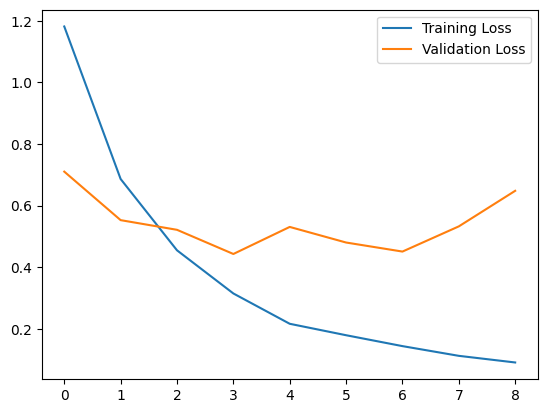

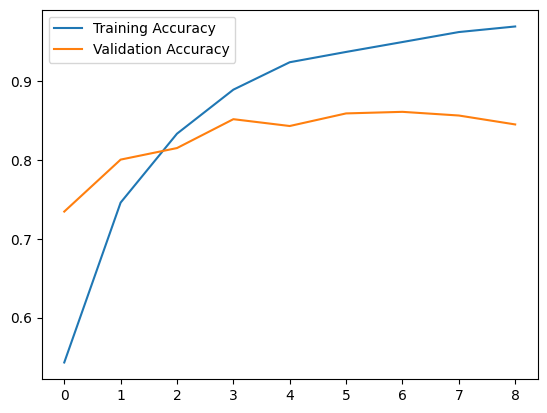

In [27]:
# Plot the losses and accuracies
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.show()

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.show()

C:\Users\waiho\AppData\Local\Temp\ipykernel_18112\1594203923.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficientnet_v2_s.load_state_dict(torch.load('efficientnet_v


Accuracy: 0.8180

F1-Score: 0.8173

Precision: 0.8194

Recall: 0.8180


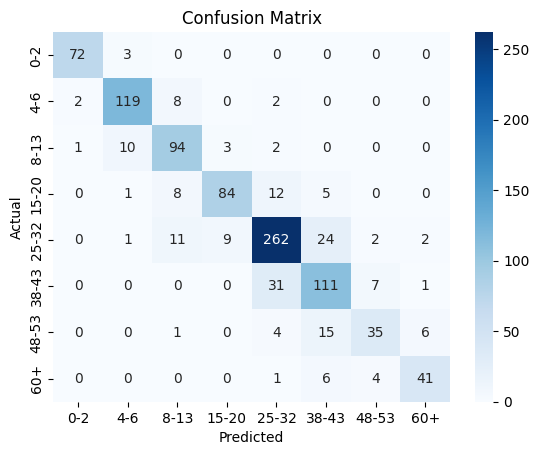

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns

# Evaluate the model
efficientnet_v2_s.load_state_dict(torch.load('efficientnet_v2_s_age.pth'))
efficientnet_v2_s.to(device)

efficientnet_v2_s.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = efficientnet_v2_s(images)
    predicted = outputs.argmax(1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())

# Calculate confusion matrix 
cm = confusion_matrix(all_labels, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(label2id.keys()), yticklabels=list(label2id.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Calculate Accuracy, F1-score, Precision, and Recall
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print(f'\nAccuracy: {accuracy:.4f}')
print(f'\nF1-Score: {f1:.4f}')
print(f'\nPrecision: {precision:.4f}')
print(f'\nRecall: {recall:.4f}')

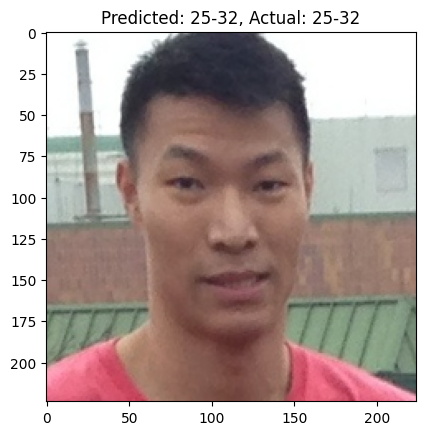

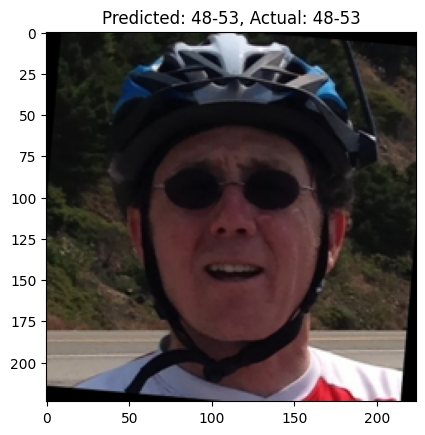

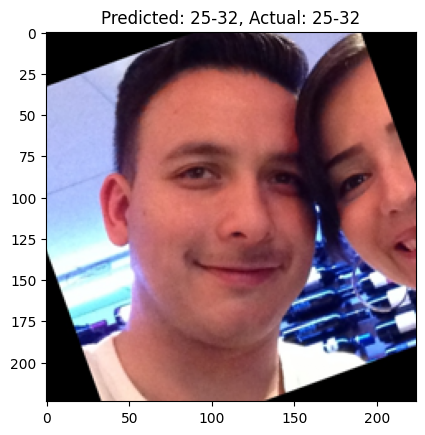

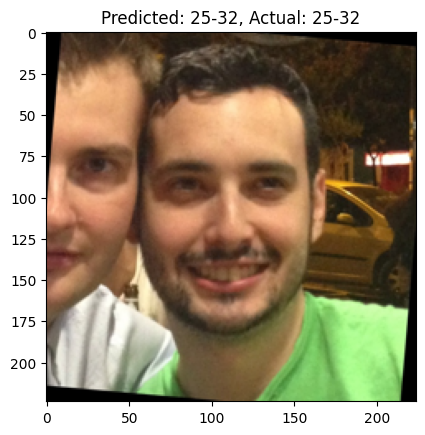

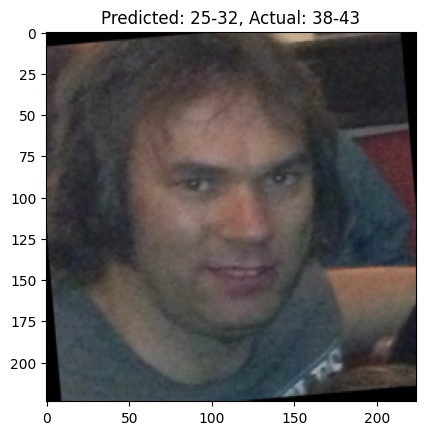

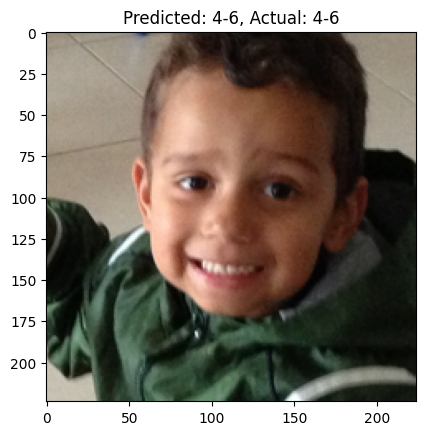

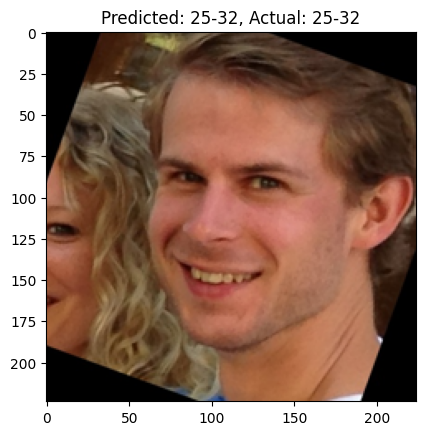

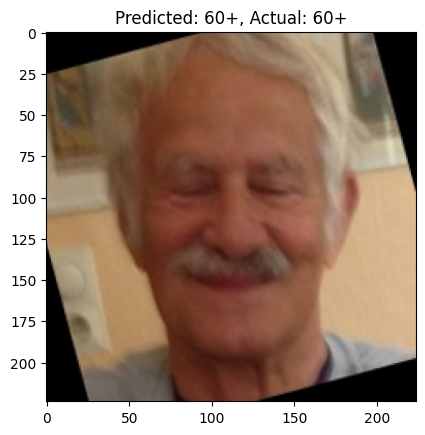

In [29]:
# Show some predictions
efficientnet_v2_s.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = efficientnet_v2_s(images)
predicted = outputs.argmax(1)
for i in range(8):
  plt.imshow(images[i].cpu().permute(1, 2, 0))
  predicted_gender = id2label[predicted[i].item()]
  actual_gender = id2label[labels[i].item()]
  plt.title(f'Predicted: {predicted_gender}, Actual: {actual_gender}')
  plt.show()

### Fine-tune the model on gender

In [25]:
labels = ["female", "male"]
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

In [26]:
# Create the datasets with gender labels
# Set label2id as None as gender labels have already been encoded as 0 and 1 with the 'male' column
train_dataset = ImageDataset(train_df.reset_index(drop=True), label="male", label2id=None, img_dir='./faces/', dim=dim, transform=transform_image)
val_dataset = ImageDataset(val_df.reset_index(drop=True), label="male", label2id=None, img_dir='./faces/', dim=dim)
test_dataset = ImageDataset(test_df.reset_index(drop=True), label="male", label2id=None, img_dir='./faces/', dim=dim)

In [27]:
len(train_dataset), len(val_dataset), len(test_dataset)

(12000, 1500, 1000)

In [28]:
# Define the dataloaders
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
from torchvision.models import efficientnet_v2_s
# Load model trained on age
efficientnet_v2_s = efficientnet_v2_s()
efficientnet_v2_s.classifier[1] = torch.nn.Linear(efficientnet_v2_s.classifier[1].in_features, len(train_dataset.annotations_df['age'].unique()))
efficientnet_v2_s.load_state_dict(torch.load('efficientnet_v2_s_age.pth'))
# Change to 2 classes
efficientnet_v2_s.classifier[1] = torch.nn.Linear(efficientnet_v2_s.classifier[1].in_features, len(train_dataset.annotations_df['gender'].unique()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
efficientnet_v2_s.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [30]:
# Check the number of parameters
total_params = sum([param.numel() for param in efficientnet_v2_s.parameters()])
print(f'{total_params:,} total parameters.')

20,180,050 total parameters.


In [31]:
# Define the loss function and the optimizer
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(efficientnet_v2_s.parameters(), lr=0.0001)

# Define early stopping
class EarlyStopper:
  def __init__(self, patience=5, min_delta=0.001):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.min_loss = float('inf')

  def early_stop(self, loss):
    if loss < self.min_loss:
      self.min_loss = loss
      self.counter = 0
    elif loss > (self.min_loss + self.min_delta):
      self.counter += 1
      if self.counter >= self.patience:
        return True
    return False

early_stopper = EarlyStopper(patience=5, min_delta=0.001)

In [32]:
# Train the model
n_epochs = 100

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
min_val_loss = float('inf')

for epoch in range(n_epochs):
  print(f'===== Epoch {epoch+1} =====')
  train_loss = 0.0
  val_loss = 0.0
  train_accuracy = 0
  val_accuracy = 0

  # Training
  efficientnet_v2_s.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = efficientnet_v2_s(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_accuracy += (outputs.argmax(1) == labels).sum().item()
  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_accuracy /= len(train_loader.dataset)
  train_accuracies.append(train_accuracy)

  print(f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')

  # Validation
  efficientnet_v2_s.eval()
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = efficientnet_v2_s(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
      val_accuracy += (outputs.argmax(1) == labels).sum().item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_accuracy /= len(val_loader.dataset)
  val_accuracies.append(val_accuracy)

  print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

  # Save the best model
  if val_loss < min_val_loss:
    torch.save(efficientnet_v2_s.state_dict(), 'efficientnet_v2_s_gender_w_age.pth')
    min_val_loss = val_loss

  # Early stopping
  if early_stopper.early_stop(val_loss):
    print('Early stopping')
    break

===== Epoch 1 =====
Training Loss: 0.1782, Training Accuracy: 0.9270
Validation Loss: 0.0808, Validation Accuracy: 0.9720
===== Epoch 2 =====
Training Loss: 0.0714, Training Accuracy: 0.9746
Validation Loss: 0.0642, Validation Accuracy: 0.9773
===== Epoch 3 =====
Training Loss: 0.0428, Training Accuracy: 0.9855
Validation Loss: 0.0545, Validation Accuracy: 0.9800
===== Epoch 4 =====
Training Loss: 0.0347, Training Accuracy: 0.9878
Validation Loss: 0.0602, Validation Accuracy: 0.9793
===== Epoch 5 =====
Training Loss: 0.0257, Training Accuracy: 0.9912
Validation Loss: 0.0682, Validation Accuracy: 0.9767
===== Epoch 6 =====
Training Loss: 0.0241, Training Accuracy: 0.9927
Validation Loss: 0.0664, Validation Accuracy: 0.9767
===== Epoch 7 =====
Training Loss: 0.0227, Training Accuracy: 0.9923
Validation Loss: 0.0688, Validation Accuracy: 0.9753
===== Epoch 8 =====
Training Loss: 0.0191, Training Accuracy: 0.9928
Validation Loss: 0.0550, Validation Accuracy: 0.9820
===== Epoch 9 =====
Trai

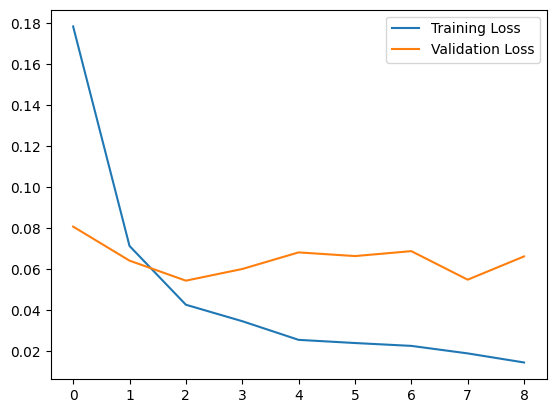

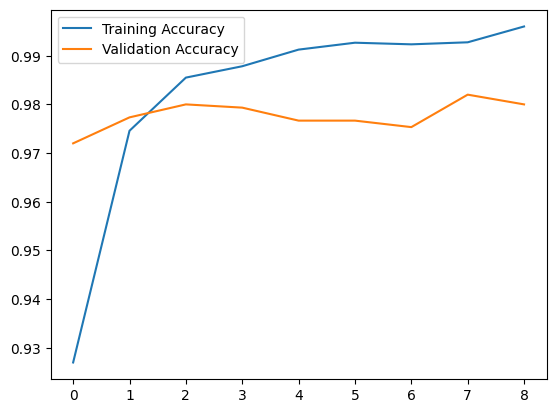

In [33]:
# Plot the losses and accuracies
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.show()

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.show()

C:\Users\waiho\AppData\Local\Temp\ipykernel_18112\2084875124.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficientnet_v2_s.load_state_dict(torch.load('efficientnet_v


Accuracy: 0.9810

F1-Score: 0.9810

Precision: 0.9810

Recall: 0.9810


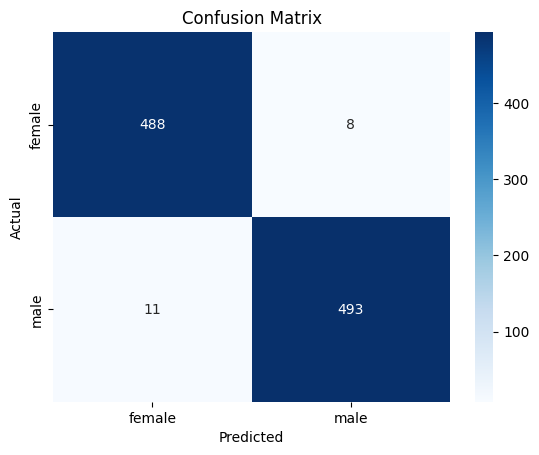

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns

# Evaluate the model
efficientnet_v2_s.load_state_dict(torch.load('efficientnet_v2_s_gender_w_age.pth'))
efficientnet_v2_s.to(device)

efficientnet_v2_s.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = efficientnet_v2_s(images)
    predicted = outputs.argmax(1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())

# Calculate confusion matrix 
cm = confusion_matrix(all_labels, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(label2id.keys()), yticklabels=list(label2id.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Calculate Accuracy, F1-score, Precision, and Recall
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print(f'\nAccuracy: {accuracy:.4f}')
print(f'\nF1-Score: {f1:.4f}')
print(f'\nPrecision: {precision:.4f}')
print(f'\nRecall: {recall:.4f}')

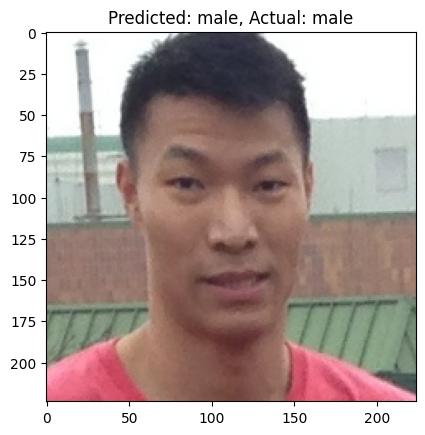

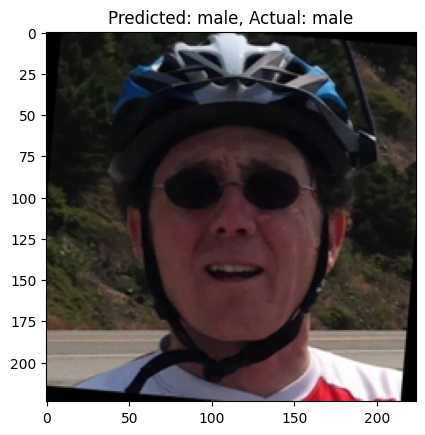

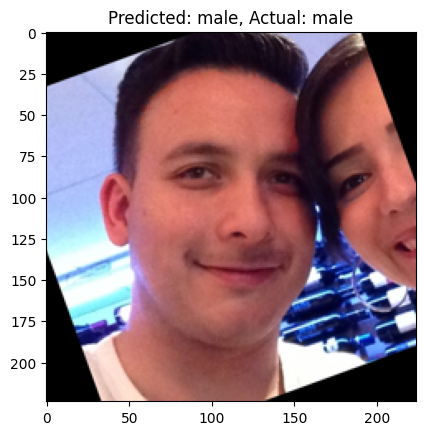

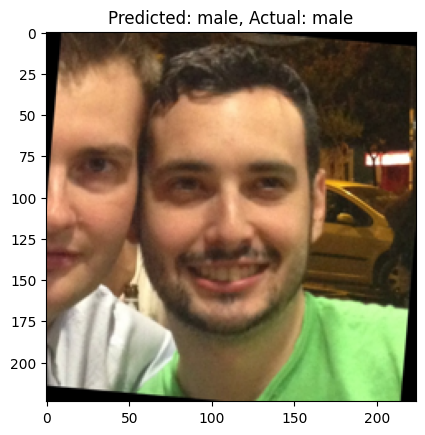

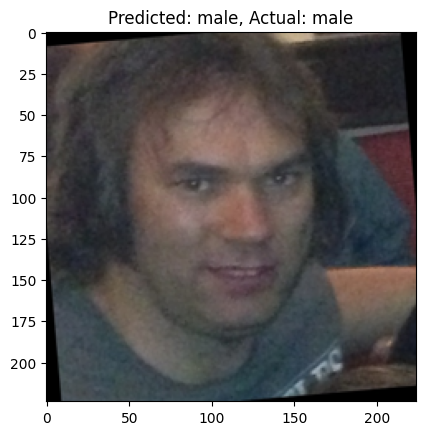

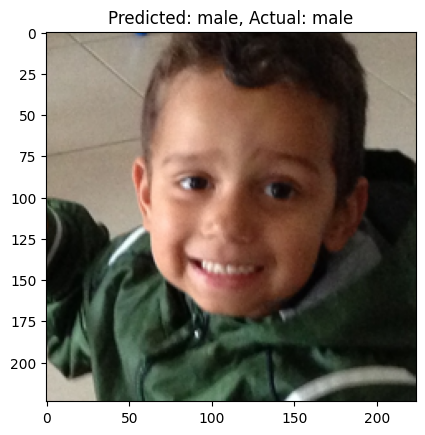

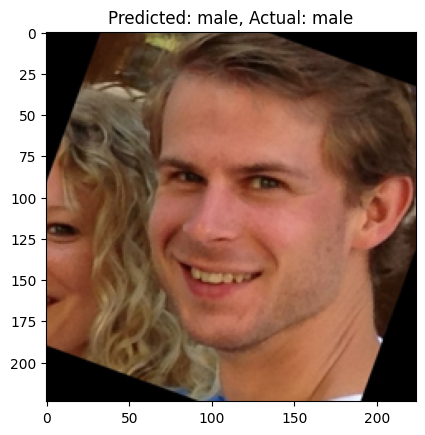

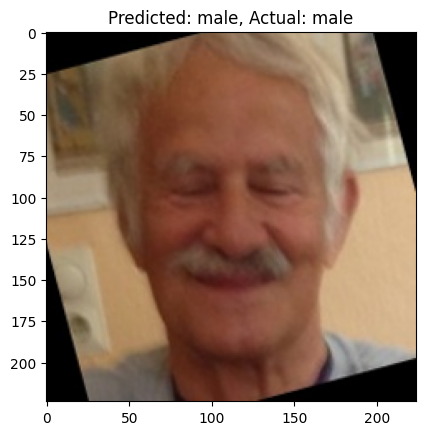

In [35]:
# Show some predictions
efficientnet_v2_s.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = efficientnet_v2_s(images)
predicted = outputs.argmax(1)
for i in range(8):
  plt.imshow(images[i].cpu().permute(1, 2, 0))
  predicted_gender = id2label[predicted[i].item()]
  actual_gender = id2label[labels[i].item()]
  plt.title(f'Predicted: {predicted_gender}, Actual: {actual_gender}')
  plt.show()